In [1]:
# Requires gdsfactory >= 7.x
import gdsfactory as gf
from gdsfactory import boolean
from gdsfactory.technology import LayerStack, LayerLevel
import numpy as np

In [2]:
# --- Parameters (µm) ---
WG_WIDTH_UM       = 0.8
CORE_THICKNESS    = 0.30
BOX_THICKNESS     = 2.0
CLAD_THICKNESS    = 3.0
etch_depth = 3*CORE_THICKNESS

PITCH             = 127.0                    # separation between facet endpoints
repeats = 6
straight_length = 1000
extra_length = 1000
RADIUS            = (PITCH / 2.0) - 5.8 #euler bends error             # 63.5 µm for exact 127 µm vertical offset
FACET_STRAIGHT    = 100.0                     # straight from edge before/after the bend
CHIP_W, CHIP_H    = PITCH*6*repeats, straight_length*2             # BOX & cladding rectangles

# --- Layers ---
L_WG   = (1, 0)   # core
L_BOX  = (2, 0)   # BOX (substrate)
# L_BOX_ETCH = (3,0)
L_CLAD = (3, 0)   # cladding

In [3]:


# --- Layer stack (optional, for cross-section/sims) ---
layer_stack = LayerStack(
    layers=dict(
        core=LayerLevel(layer=L_WG, thickness=CORE_THICKNESS, zmin=0.0, material="LiNbO3"),
        box=LayerLevel(layer=L_BOX, thickness=BOX_THICKNESS, zmin=-BOX_THICKNESS-etch_depth, material="SiO2"),
        # box_etch=LayerLevel(layer=L_BOX_ETCH, thickness=etch_depth, zmin=-etch_depth, material="SiO2"),
        clad=LayerLevel(layer=L_CLAD, thickness=CLAD_THICKNESS, zmin=CORE_THICKNESS, material="Air"),
    )
)

In [4]:
# --- Cross-section (LN strip) ---
xs_ln = gf.cross_section.strip(width=WG_WIDTH_UM, layer=L_WG)


In [5]:
# ---------- Cross-section ----------
xs_ln = gf.cross_section.strip(width=WG_WIDTH_UM, layer=L_WG)

# ---------- Reusable loopback builder ----------
def make_loopback_euler(straight_len: float, offset_y: float = 0.0, angle_sign: int = +1) -> gf.Component:
    """
    Builds ONE 180° Euler hairpin with radius=RADIUS.
    Places its ports on the LEFT chip edge (x = -CHIP_W/2), shifted by 'offset_y' in y.

    Args:
        straight_len: straight length before and after the 180° bend (µm)
        offset_y:     vertical offset applied to this loop (µm)
        angle_sign:   +1 => bends "up" (+180°), -1 => bends "down" (-180°)

    Returns:
        gf.Component with two ports: 'o1' (lower) and 'o2' (upper), both facing -x.
    """
    # Path: straight → 180° Euler → straight
    p = gf.path.Path()
    p += gf.path.straight(straight_len)
    p += gf.path.euler(radius=RADIUS, angle=180 * angle_sign)
    p += gf.path.straight(straight_len)
    loop = p.extrude(cross_section=xs_ln)

    c = gf.Component()
    r = c << loop

    # Place so ports lie on left chip edge, centered w.r.t the bend, then apply offset
    # For a +180° loop, the intrinsic port y's are (-R, +R). We shift by +offset_y.
    r.move((0,offset_y))

    # Expose ports
    c.add_port("o1", port=r.ports["o1"])
    c.add_port("o2", port=r.ports["o2"])
    return c

gap=127
# ---------- Top level: call it thrice with your parameters ----------
@gf.cell
def ln_three_loopbacks(trench_l, i) -> gf.Component:
    c = gf.Component()

    trench1 = c.add_ref(gf.components.rectangle(size=(trench_l,3*WG_WIDTH_UM), layer=L_BOX))
    trench2 = c.add_ref(gf.components.rectangle(size=(trench_l,3*WG_WIDTH_UM), layer=L_BOX))
    
    trench1.move((straight_length+extra_length-100-trench_l,3.5*WG_WIDTH_UM))
    trench2.move((straight_length+extra_length-100-trench_l,-6.5*WG_WIDTH_UM))

    A = c << make_loopback_euler(straight_len=straight_length+extra_length,  offset_y=0.0,      angle_sign=+1)
    B = c << make_loopback_euler(straight_len=straight_length/2+extra_length,  offset_y=2*gap,    angle_sign=+1)
    C = c << make_loopback_euler(straight_len=straight_length/2+extra_length, offset_y=-2*gap,    angle_sign=+1)

    # Rename ports for clarity (A_o1/A_o2, etc.)
    # c.add_port("A_o1", port=A.ports["o1"]); c.add_port("A_o2", port=A.ports["o2"])
    # c.add_port("B_o1", port=B.ports["o1"]); c.add_port("B_o2", port=B.ports["o2"])
    # c.add_port("C_o1", port=C.ports["o1"]); c.add_port("C_o2", port=C.ports["o2"])

    return c

# # ---- Build & plot ----
# c = ln_three_loopbacks()
# c.plot()
# distance = abs(c.ports["C_o1"].center[1] - c.ports["C_o2"].center[1])

# print(distance)

In [6]:
import gdsfactory as gf
xs = gf.cross_section.strip(width=1.9, layer=(1,0))

def spacing_for_radius(R):
    p = gf.path.Path()
    p += gf.path.straight(100)
    p += gf.path.euler(radius=R, angle=180)
    p += gf.path.straight(100)
    c = p.extrude(cross_section=xs)
    return abs(c.ports["o2"].center[1] - c.ports["o1"].center[1])

for testR in [40, 50, 55, 56 ,57 , 57.1, 57.2, 57.3, 57.4, 57.5, 57.6, 57.7, 57.8, 57.9, 58 ,59, 60]:
    print(testR, spacing_for_radius(testR))

40 88046
50 110057
55 121063
56 123264
57 125465
57.1 125685
57.2 125906
57.3 126126
57.4 126346
57.5 126566
57.6 126786
57.7 127006
57.8 127226
57.9 127446
58 127666
59 129868
60 132069


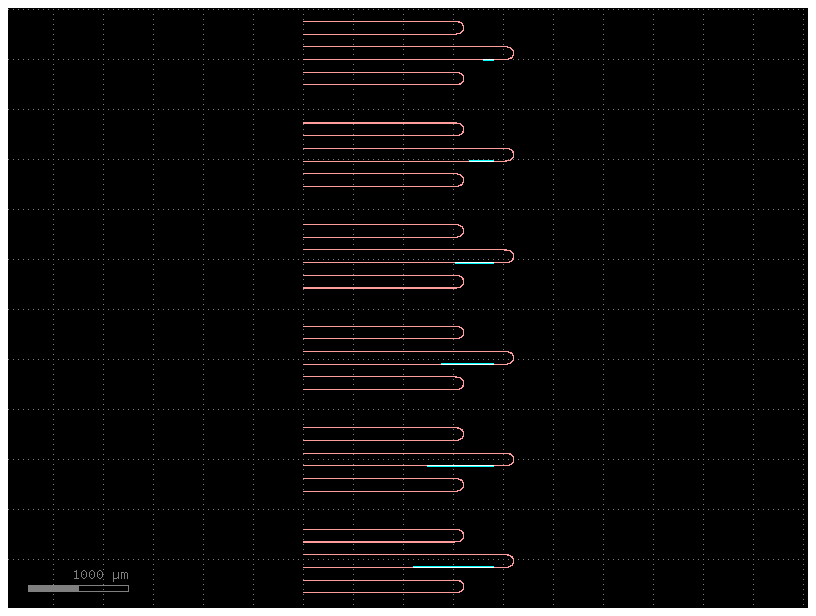

In [7]:
trench_lengths = np.linspace(straight_length/10, straight_length-200, repeats)
c = gf.Component("multiple loopbacks")
for i in range(repeats):
    sub = c << ln_three_loopbacks(trench_lengths[i], i)
    sub.move((0, -8*i*gap))

c.plot()


In [8]:
c.show()

2025-11-14 17:26:27.687 | INFO     | kfactory.kcell:show:8777 - klive v0.3.3: Opened file 'C:\Users\PRAVAL~1\AppData\Local\Temp\4020511028.gds'


In [9]:
@gf.cell
def one_loopback_connected(trench_l, i) -> gf.Component:
    c = gf.Component()

    trench1 = c.add_ref(gf.components.rectangle(size=(trench_l,3*WG_WIDTH_UM), layer=L_BOX))
    trench2 = c.add_ref(gf.components.rectangle(size=(trench_l,3*WG_WIDTH_UM), layer=L_BOX))
    trench3 = c.add_ref(gf.components.rectangle(size=(3*WG_WIDTH_UM, 7*WG_WIDTH_UM), layer=L_BOX))
    
    trench1.move((straight_length+extra_length-100-trench_l,3.5*WG_WIDTH_UM))
    trench2.move((straight_length+extra_length-100-trench_l,-6.5*WG_WIDTH_UM))
    trench3.move((straight_length+extra_length-100-3*WG_WIDTH_UM, -3.5*WG_WIDTH_UM))

    A = c << make_loopback_euler(straight_len=straight_length+extra_length,  offset_y=0.0,      angle_sign=+1)

    return c

In [10]:
for i in range(repeats):

    sub_connected = c <<  one_loopback_connected(trench_lengths[i], i)
    sub_connected.move((0, -(4 + 8*i) * gap))


last_wg = c << make_loopback_euler(straight_len=straight_length/2+extra_length,  offset_y=0.0,      angle_sign=+1)
last_wg.move((0, -(8*repeats-2) * gap))


multiple loopbacks: ports ['o1', 'o2'], vinsts=[] info=Info() kcl=KCLayout(name='DEFAULT', layout=<klayout.dbcore.Layout object at 0x000001CE11831070>, layer_enclosures=LayerEnclosureModel(root={'78687732': LayerEnclosure(layer_sections={}, main_layer=WG (1/0), yaml_tag='!Enclosure'), '5c226817': LayerEnclosure(layer_sections={}, main_layer=SLAB150 (2/0), yaml_tag='!Enclosure')}), cross_sections={'78687732_1900': SymmetricalCrossSection(width=1900, enclosure=LayerEnclosure(layer_sections={}, main_layer=WG (1/0), yaml_tag='!Enclosure'), name='78687732_1900'), '5c226817_2400': SymmetricalCrossSection(width=2400, enclosure=LayerEnclosure(layer_sections={}, main_layer=SLAB150 (2/0), yaml_tag='!Enclosure'), name='5c226817_2400'), '5c226817_100000': SymmetricalCrossSection(width=100000, enclosure=LayerEnclosure(layer_sections={}, main_layer=SLAB150 (2/0), yaml_tag='!Enclosure'), name='5c226817_100000'), '78687732_800': SymmetricalCrossSection(width=800, enclosure=LayerEnclosure(layer_section

2025-11-14 17:26:28.300 | INFO     | kfactory.kcell:show:8777 - klive v0.3.3: Opened file 'C:\Users\PRAVAL~1\AppData\Local\Temp\233462985.gds'


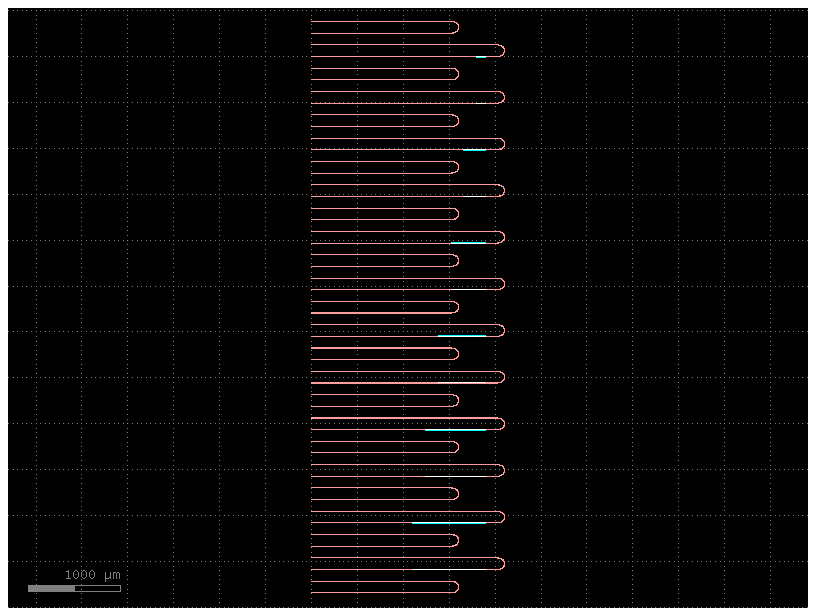

In [11]:
c.plot()
c.show()